# 🛒 Retail Supply Chain Sales Dataset — Exploratory Data Analysis
**Author:** Kai Hoang  
**Date:** July 2025  
**Dataset:** RetailSupplyChainSalesDataset.csv  
**Datasource:** https://www.kaggle.com/datasets/shandeep777/retail-supply-chain-sales-dataset


---
## 🎯 Objective
Understand the structure, patterns, and key insights hidden in retail sales data across customers, products, regions, and time. 

### Table of Contents
1. [Import Libraries](#1)
2. [Load & Inspect the Data](#2)
3. [Data Cleaning & Type Fixing](#3)
4. [Univariate Analysis — Understanding Each Column](#4)
5. [Bivariate & Multivariate Analysis](#5)
6. [Time-Series Analysis](#6)
7. [Profitability Deep-Dive](#7)
8. [Returns Analysis](#8)
9. [Key Takeaways & Next Steps](#9)
10. [Connect to SQL Server — RetailSupplyChain DB](#10)

---
## 1. Import Libraries <a id='1'></a>

In [3]:
# ── Standard imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Notebook display settings ─────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
COLORS = sns.color_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. Load & Inspect the Data <a id='2'></a>

In [55]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Project\Supply Chain Analyst\Supply Chain Raw Data\Retail Supply Chain Sales Dataset\Retail-Supply-Chain-Sales-Dataset.csv')

print(f' Dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns')

 Dataset loaded — 9,994 rows × 23 columns


In [8]:
# ── First five rows ───────────────────────────────────────────────────────────
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/12/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/11/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/11/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.37,2,0.20,2.52


In [9]:
# ── Last five rows ────────────────────────────────────────────────────────────
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,21/01/2014,23/01/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,Cassandra Brandow,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,Not,25.25,3,0.20,4.10
9990,9991,CA-2017-121258,26/02/2017,3/03/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,Anna Andreadi,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,Yes,91.96,2,0.00,15.63
9991,9992,CA-2017-121258,26/02/2017,3/03/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,Anna Andreadi,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,Yes,258.58,2,0.20,19.39
9992,9993,CA-2017-121258,26/02/2017,3/03/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,Anna Andreadi,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",Yes,29.60,4,0.00,13.32
9993,9994,CA-2017-119914,5/04/2017,5/09/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,Anna Andreadi,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",Not,243.16,2,0.00,72.95


In [10]:
# ── Data types ────────────────────────────────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row ID               9994 non-null   int64  
 1   Order ID             9994 non-null   str    
 2   Order Date           9994 non-null   str    
 3   Ship Date            9994 non-null   str    
 4   Ship Mode            9994 non-null   str    
 5   Customer ID          9994 non-null   str    
 6   Customer Name        9994 non-null   str    
 7   Segment              9994 non-null   str    
 8   Country              9994 non-null   str    
 9   City                 9994 non-null   str    
 10  State                9994 non-null   str    
 11  Postal Code          9994 non-null   int64  
 12  Region               9994 non-null   str    
 13  Retail Sales People  9994 non-null   str    
 14  Product ID           9994 non-null   str    
 15  Category             9994 non-null   str    
 16 

In [11]:
# ── Statistical summary for numeric columns ───────────────────────────────────
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,"9,994.00","4,997.50","2,885.16",1.00,"2,499.25","4,997.50","7,495.75","9,994.00"
Postal Code,"9,994.00","55,190.38","32,063.69","1,040.00","23,223.00","56,430.50","90,008.00","99,301.00"
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.66,29.36,"8,399.98"


In [12]:
# ── Statistical summary for categorical columns ───────────────────────────────
df.describe(include='object').T

,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Order Date,9994,1237,9/05/2016,38
Ship Date,9994,1215,11/12/2017,44
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001


In [13]:
# ── Missing values check ──────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found in any column!')
else:
    print(missing_df)

✅ No missing values found in any column!


In [14]:
# ── Duplicate rows check ──────────────────────────────────────────────────────
dupe_count = df.duplicated().sum()
print(f'🔁 Duplicate rows: {dupe_count}')

🔁 Duplicate rows: 0


---
## 3. Data Cleaning & Type Fixing <a id='3'></a>

In [15]:
# ── Parse date columns ────────────────────────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, format='mixed')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True, format='mixed')

# ── Derive new time features ──────────────────────────────────────────────────
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order DOW']     = df['Order Date'].dt.day_name()   # Day of week

# ── Derive shipping lead time ─────────────────────────────────────────────────
df['Lead Time (days)'] = (df['Ship Date'] - df['Order Date']).dt.days

# ── Clean Returned column → boolean ───────────────────────────────────────────
df['Is Returned'] = df['Returned'].str.strip().str.lower() == 'yes'

# ── Profit margin (%) ─────────────────────────────────────────────────────────
df['Profit Margin (%)'] = (df['Profit'] / df['Sales'].replace(0, np.nan)) * 100

print(f'✅ Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Date range: {df["Order Date"].min().date()}  →  {df["Order Date"].max().date()}')

✅ Cleaned dataset: 9,994 rows × 31 columns
   Date range: 2014-01-02  →  2017-12-30


---
## 4. Univariate Analysis — Understanding Each Column <a id='4'></a>

> 💡 *Univariate = looking at one variable at a time. We ask: what does this column look like on its own?*

### 4.1 Categorical Columns — Value Counts

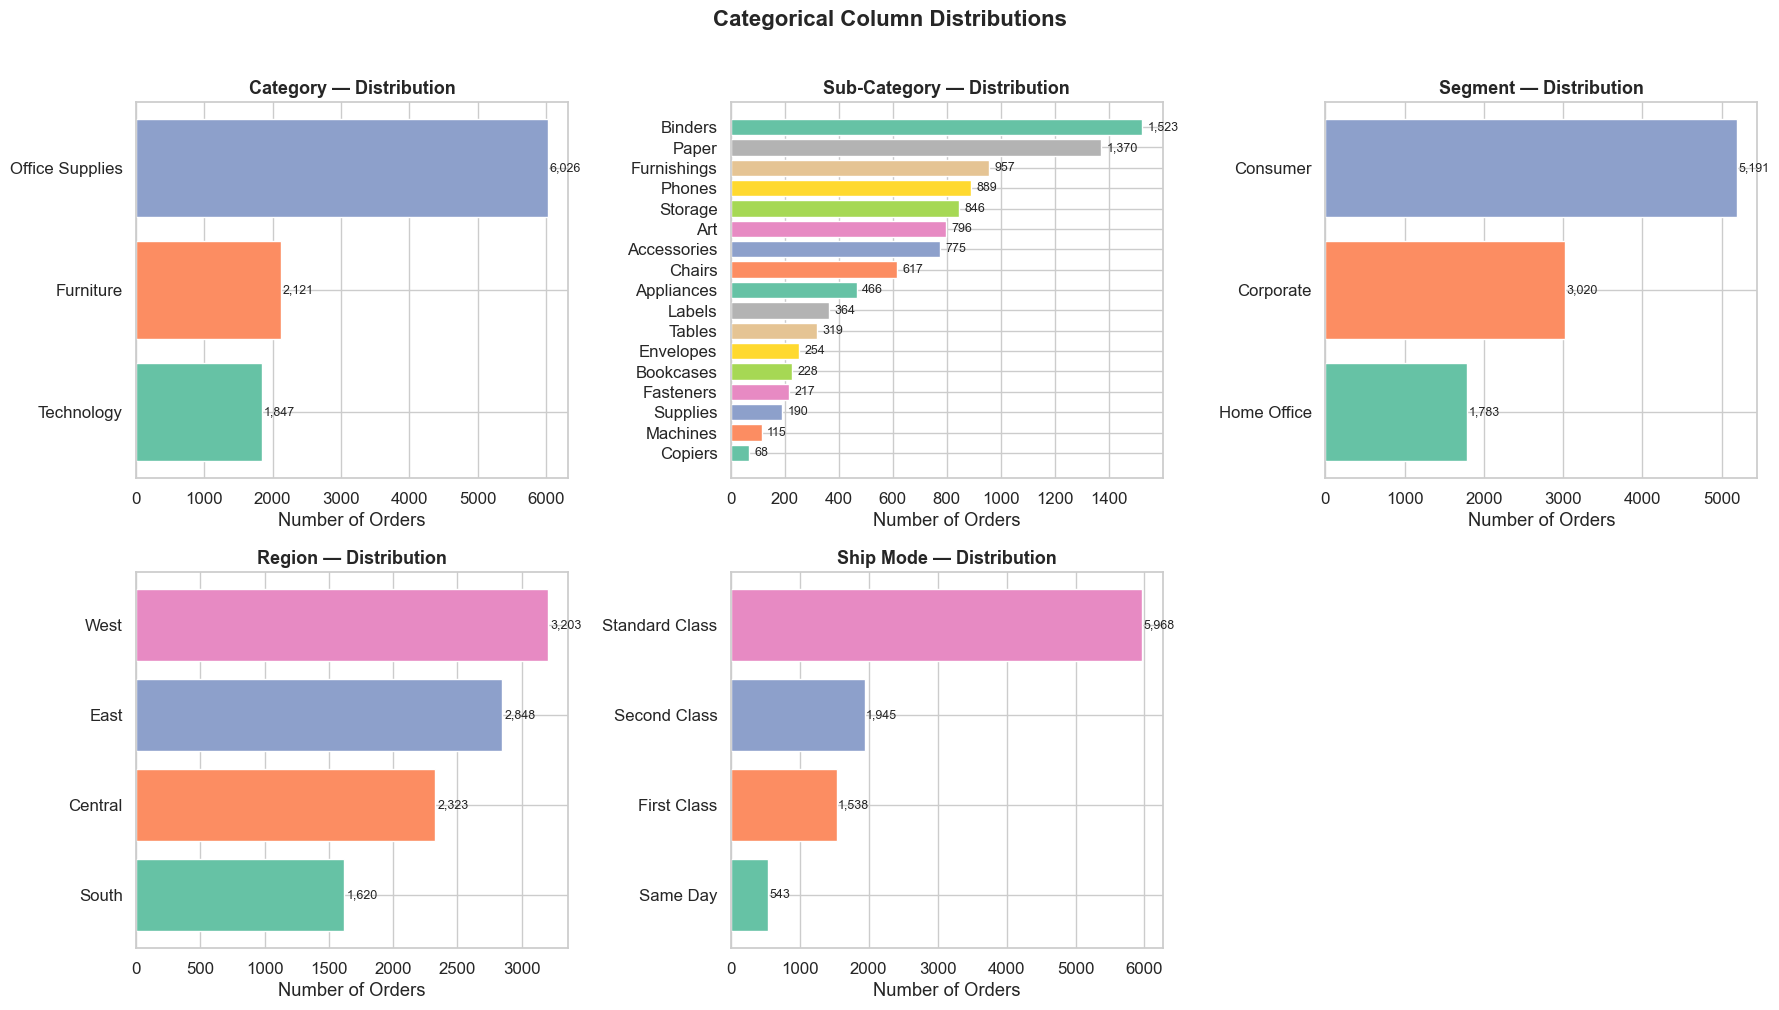


--- Category ---
Category
Office Supplies   60.30
Furniture         21.20
Technology        18.50

--- Segment ---
Segment
Consumer      51.90
Corporate     30.20
Home Office   17.80

--- Region ---
Region
West      32.00
East      28.50
Central   23.20
South     16.20


In [16]:
cat_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index[::-1], counts.values[::-1], color=COLORS)
    axes[i].set_title(f'{col} — Distribution', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Number of Orders')
    for j, v in enumerate(counts.values[::-1]):
        axes[i].text(v + 20, j, f'{v:,}', va='center', fontsize=9)

axes[-1].set_visible(False)   # hide unused subplot
plt.suptitle('Categorical Column Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print percentage breakdowns
for col in ['Category', 'Segment', 'Region']:
    print(f'\n--- {col} ---')
    print((df[col].value_counts(normalize=True) * 100).round(1).to_string())

### 4.2 Numeric Columns — Distributions

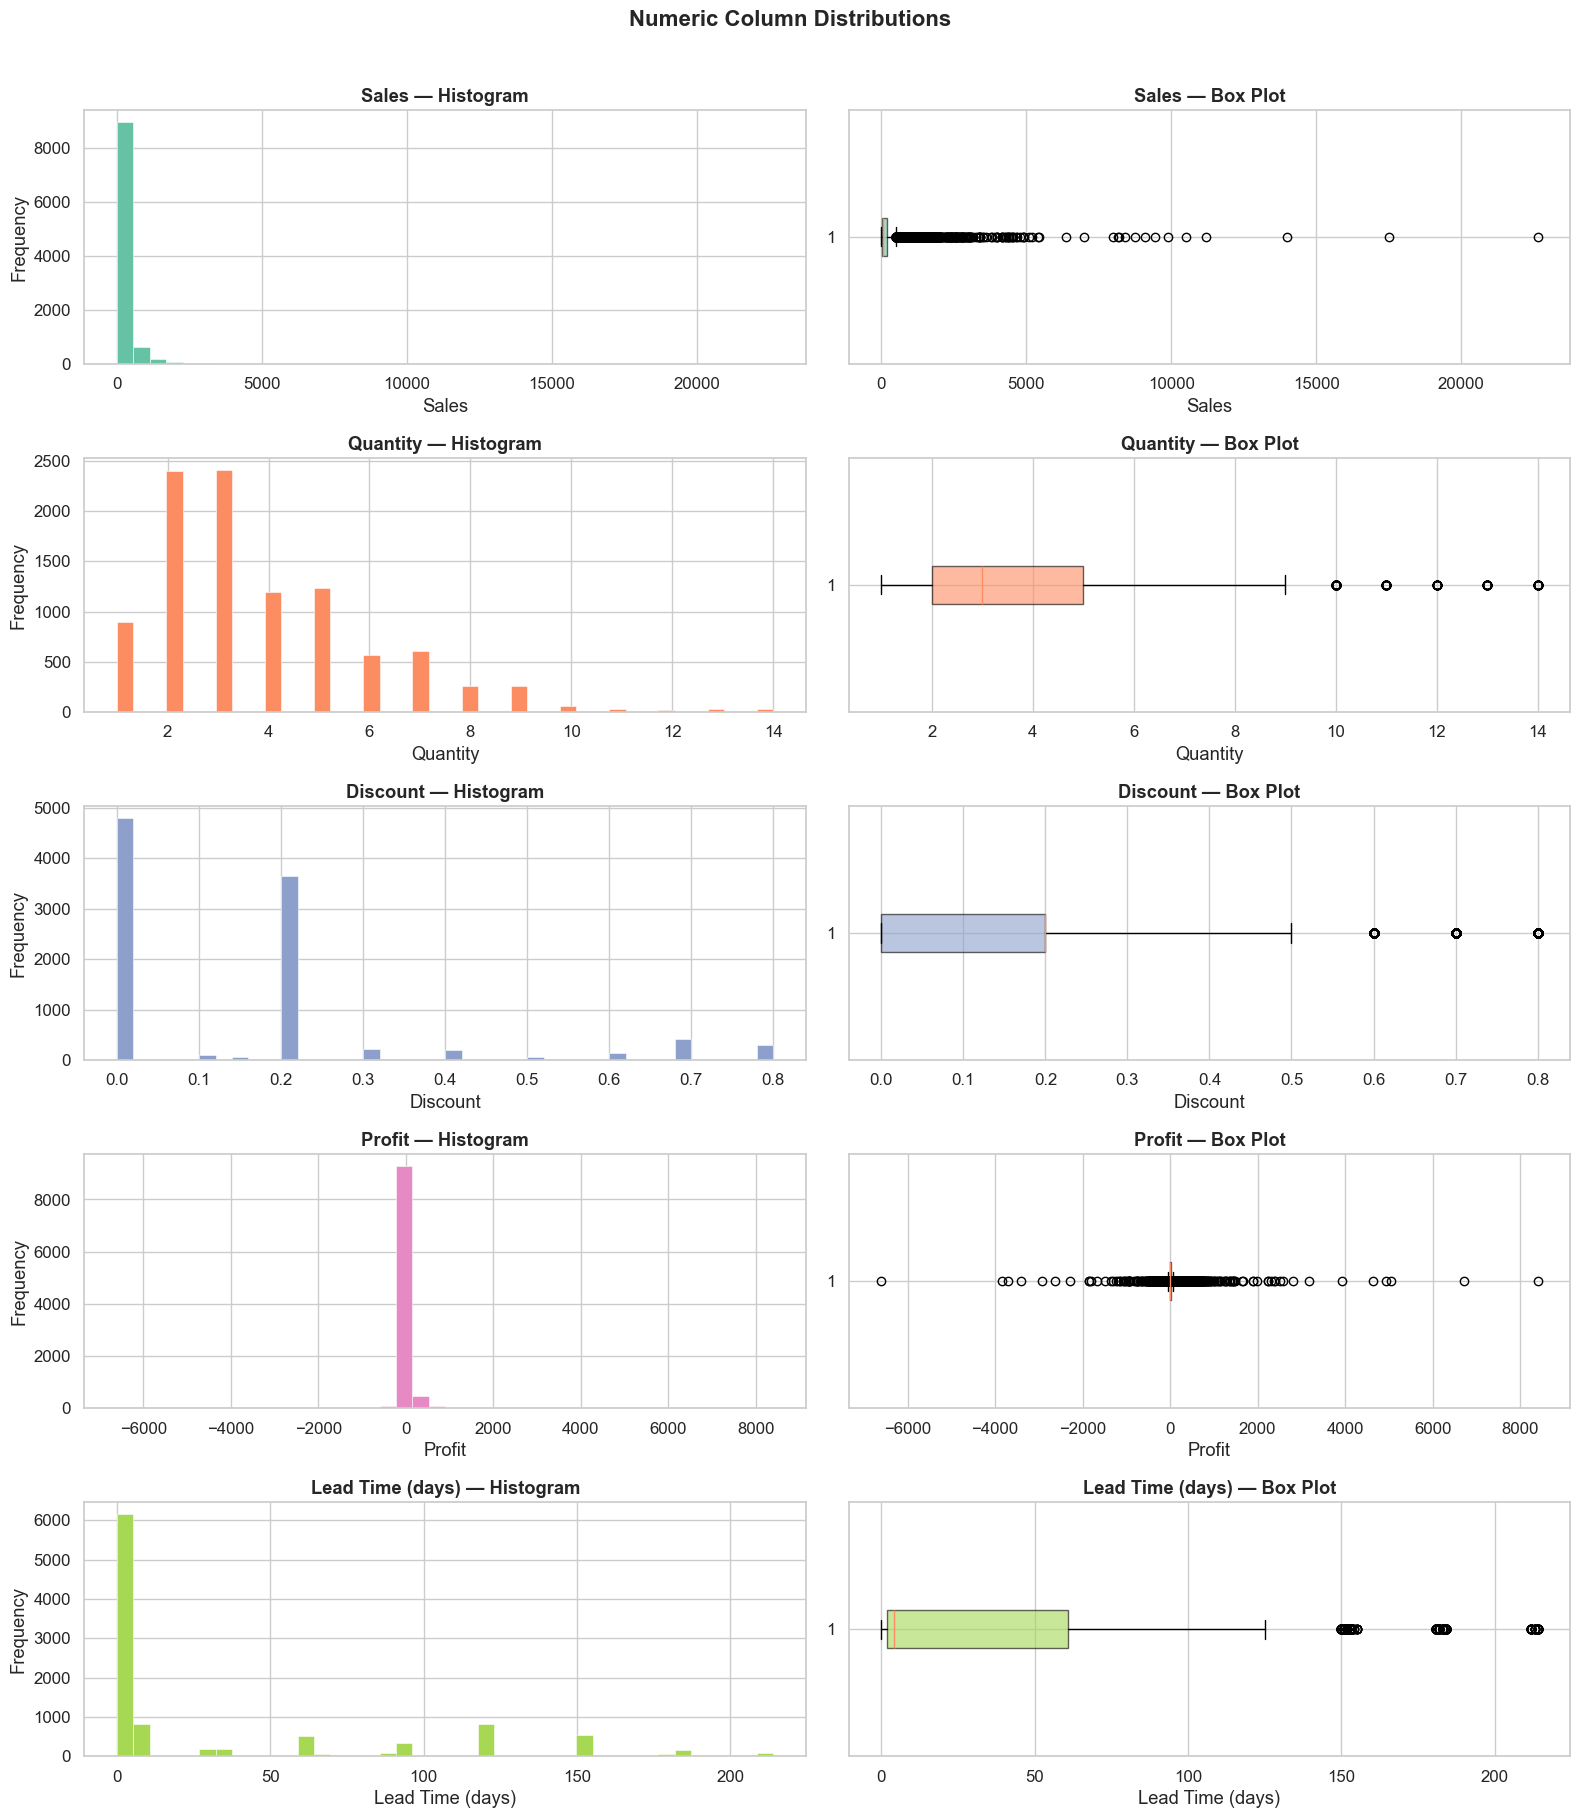


📊 Key Statistics:
                   mean  median    std       min       max
Sales            229.86   54.49 623.25      0.44 22,638.48
Quantity           3.79    3.00   2.23      1.00     14.00
Discount           0.16    0.20   0.21      0.00      0.80
Profit            28.66    8.66 234.26 -6,599.98  8,399.98
Lead Time (days)  34.61    4.00  55.06      0.00    214.00


In [17]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Lead Time (days)']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(16, 18))

for i, col in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(df[col].dropna(), bins=40, color=COLORS[i % len(COLORS)], edgecolor='white', linewidth=0.4)
    axes[i, 0].set_title(f'{col} — Histogram', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.6))
    axes[i, 1].set_title(f'{col} — Box Plot', fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.suptitle('Numeric Column Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Key stats table
print('\n📊 Key Statistics:')
print(df[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T.round(2))

In [54]:
# ── Skewness & Kurtosis ────────────────────────────────────────────────────────
print(' Skewness & Kurtosis of Numeric Columns:')
skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(2),
    'Kurtosis': df[num_cols].kurt().round(2)
})
print(skew_kurt)
print('\n Skewness > 1 = right-skewed (long tail on right) | < -1 = left-skewed')

 Skewness & Kurtosis of Numeric Columns:
                  Skewness  Kurtosis
Sales                12.97    305.31
Quantity              1.28      1.99
Discount              1.68      2.41
Profit                7.56    397.19
Lead Time (days)      1.50      0.89

 Skewness > 1 = right-skewed (long tail on right) | < -1 = left-skewed


---
## 5. Bivariate & Multivariate Analysis <a id='5'></a>


### 5.1 Sales by Category & Segment

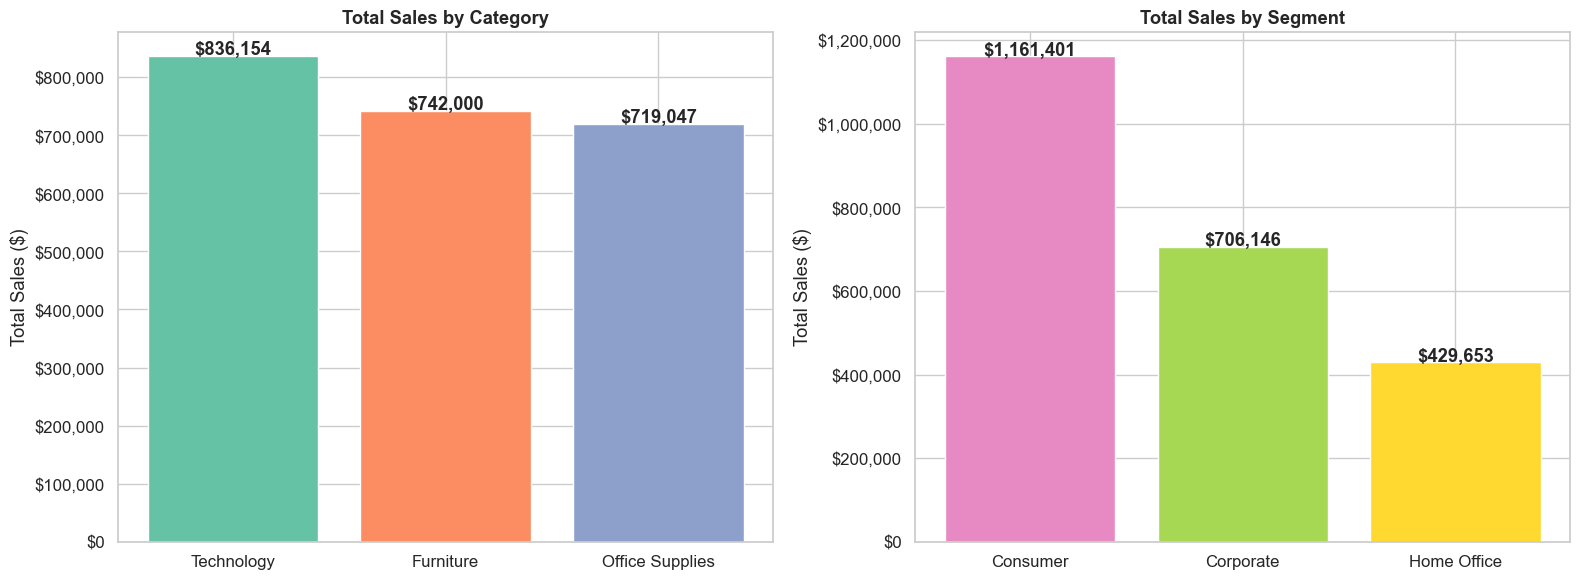

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=COLORS[:3], edgecolor='white')
axes[0].set_title('Total Sales by Category', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for j, v in enumerate(cat_sales.values):
    axes[0].text(j, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold')

# Sales by Segment
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(seg_sales.index, seg_sales.values, color=COLORS[3:6], edgecolor='white')
axes[1].set_title('Total Sales by Segment', fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for j, v in enumerate(seg_sales.values):
    axes[1].text(j, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Profit by Category & Sub-Category

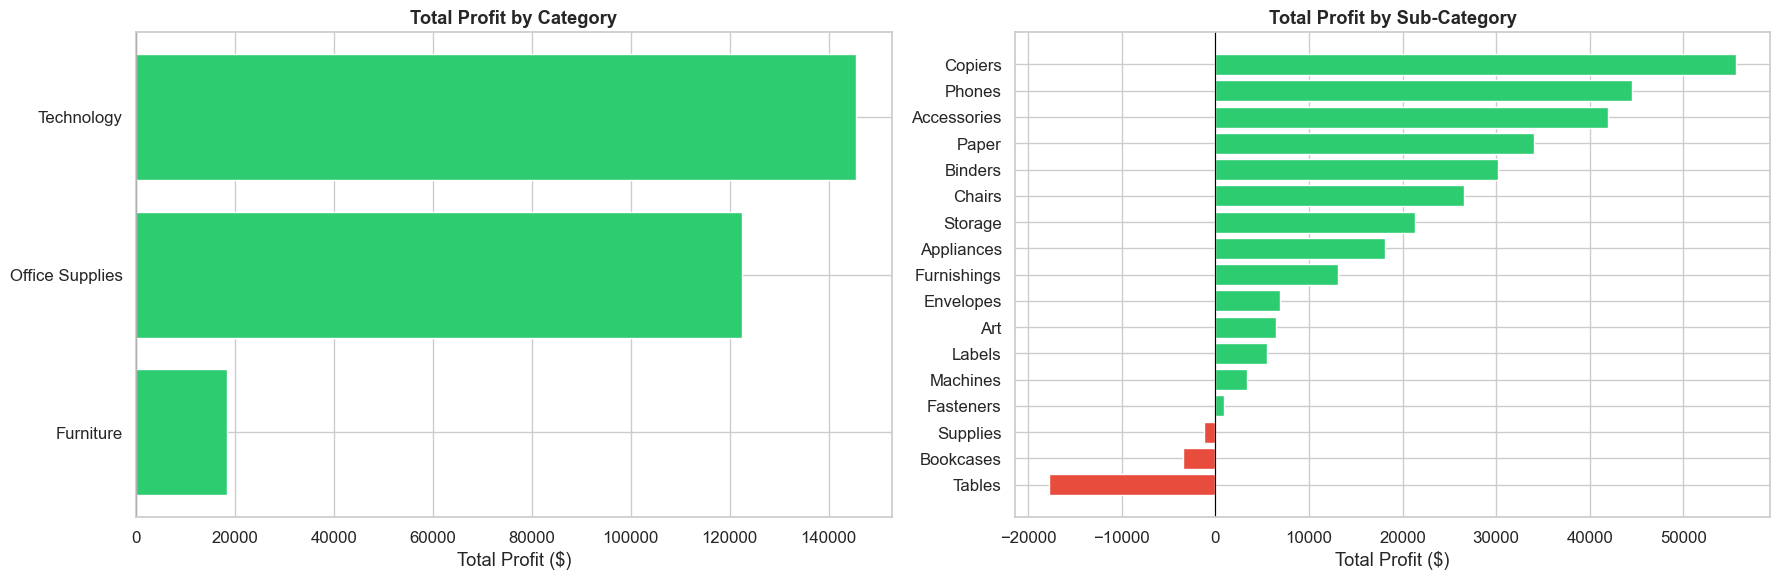

🏆 Top 5 Most Profitable Sub-Categories:
Sub-Category
Copiers       55,617.90
Phones        44,516.25
Accessories   41,936.78
Paper         34,053.34
Binders       30,221.64
Name: Profit, dtype: float64

🔴 Bottom 5 (Loss-Making) Sub-Categories:
Sub-Category
Machines      3,384.73
Fasteners       949.53
Supplies     -1,188.99
Bookcases    -3,472.56
Tables      -17,725.59
Name: Profit, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Profit by Category
cat_profit = df.groupby('Category')['Profit'].sum().sort_values()
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_profit.values]
axes[0].barh(cat_profit.index, cat_profit.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Total Profit by Category', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].axvline(0, color='black', lw=0.8)

# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
bar_colors2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in sub_profit.values]
axes[1].barh(sub_profit.index, sub_profit.values, color=bar_colors2, edgecolor='white')
axes[1].set_title('Total Profit by Sub-Category', fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

# Top 5 profitable & loss-making sub-categories
sub_profit_sorted = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print('🏆 Top 5 Most Profitable Sub-Categories:')
print(sub_profit_sorted.head())
print('\n🔴 Bottom 5 (Loss-Making) Sub-Categories:')
print(sub_profit_sorted.tail())

### 5.3 Sales & Profit by Region

  Regional Summary:
         Total_Sales  Total_Profit  Num_Orders  Avg_Discount  Profit_Margin_%
Region                                                                       
West      725,457.93    108,418.79        1611          0.11            14.90
East      678,781.36     91,522.84        1401          0.15            13.50
Central   501,239.88     39,706.45        1175          0.24             7.90
South     391,721.90     46,749.71         822          0.15            11.90


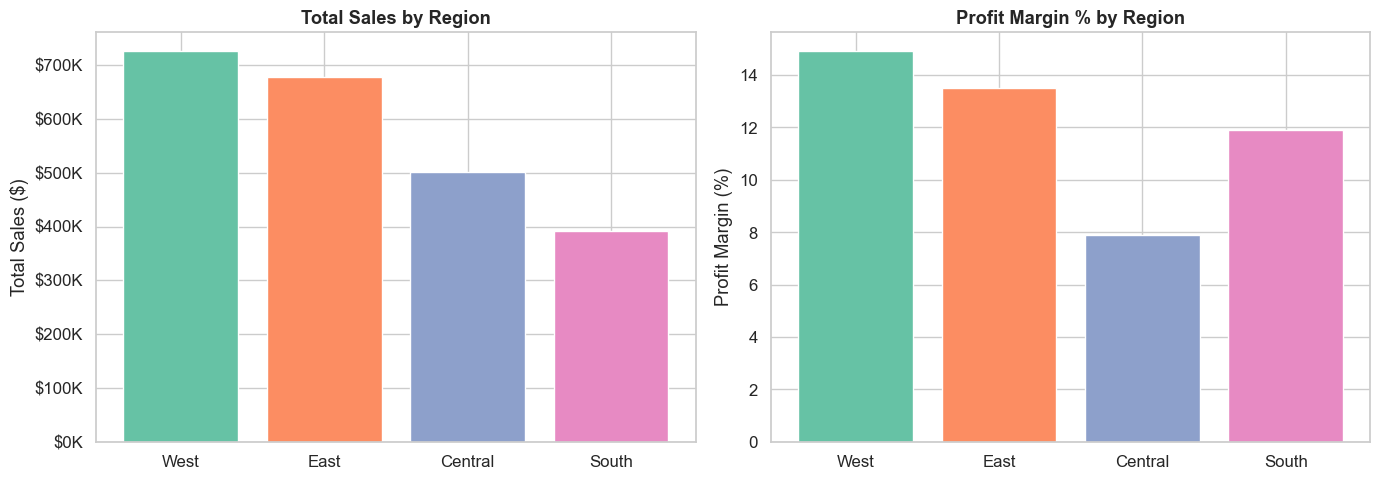

In [53]:
region_summary = df.groupby('Region').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Num_Orders    = ('Order ID', 'nunique'),
    Avg_Discount  = ('Discount', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

region_summary['Profit_Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100).round(1)
print('  Regional Summary:')
print(region_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(region_summary.index, region_summary['Total_Sales'], color=COLORS, edgecolor='white')
axes[0].set_title('Total Sales by Region', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].bar(region_summary.index, region_summary['Profit_Margin_%'], color=COLORS, edgecolor='white')
axes[1].set_title('Profit Margin % by Region', fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

### 5.4 Discount vs Profit — Scatter Plot

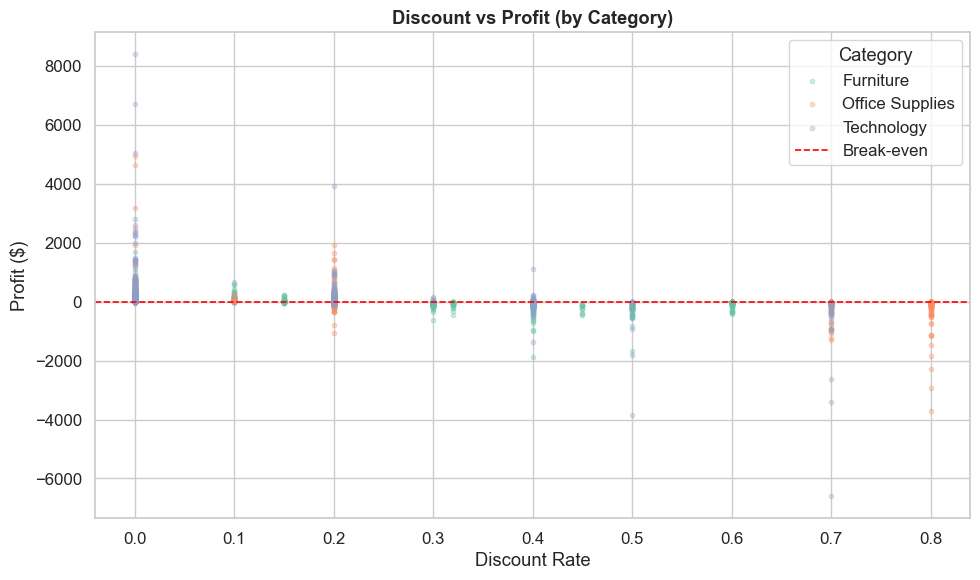

🔗 Pearson Correlation between Discount and Profit: -0.219
   (Negative = higher discounts → lower profit)


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'Furniture': COLORS[0], 'Office Supplies': COLORS[1], 'Technology': COLORS[2]}
for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'], alpha=0.3, s=10, label=cat, color=palette[cat])

ax.axhline(0, color='red', linestyle='--', lw=1.2, label='Break-even')
ax.set_title('Discount vs Profit (by Category)', fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.legend(title='Category')
plt.tight_layout()
plt.show()

# Correlation
corr = df['Discount'].corr(df['Profit'])
print(f'🔗 Pearson Correlation between Discount and Profit: {corr:.3f}')
print('   (Negative = higher discounts → lower profit)')

### 5.5 Correlation Heatmap

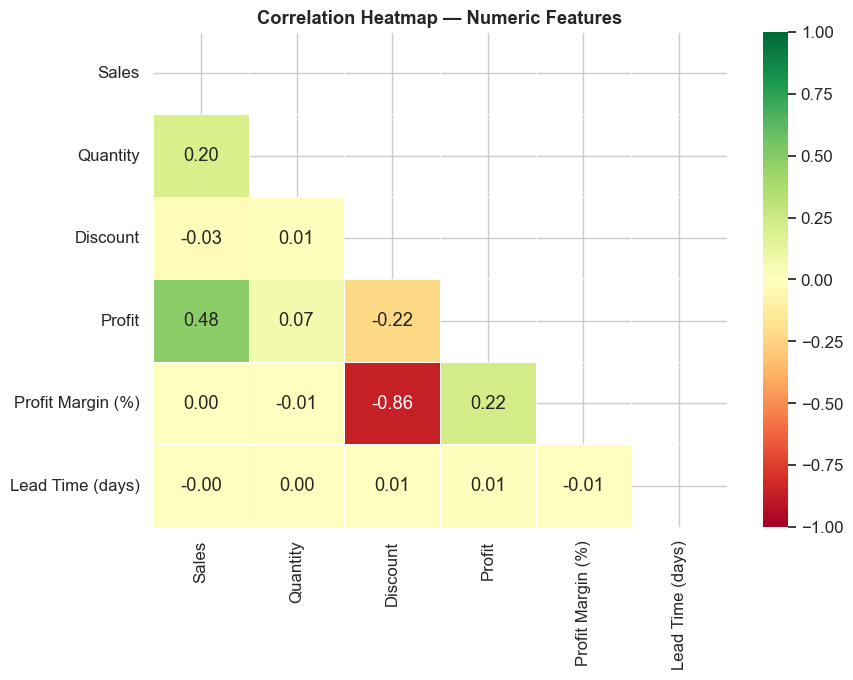

In [23]:
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin (%)', 'Lead Time (days)']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Sales by Ship Mode

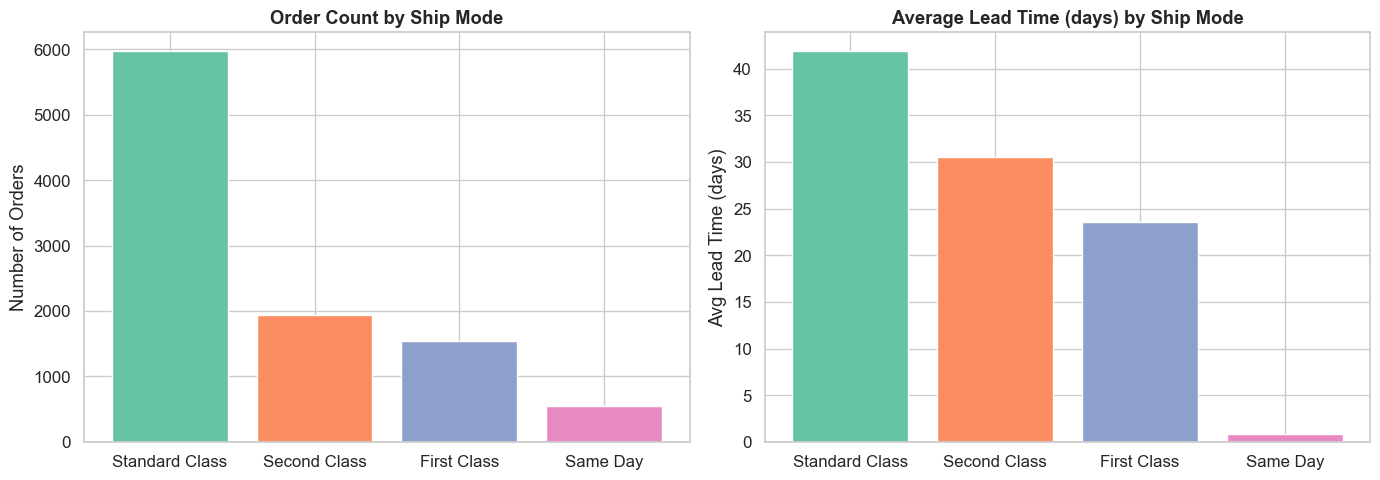


 Ship Mode Summary:
                Orders  Total_Sales  Avg_LeadTime
Ship Mode                                        
First Class       1538   351,428.43         23.54
Same Day           543   128,363.12          0.88
Second Class      1945   459,193.44         30.56
Standard Class    5968 1,358,216.08         41.85


In [52]:
ship_summary = df.groupby('Ship Mode').agg(
    Orders       = ('Order ID', 'count'),
    Total_Sales  = ('Sales', 'sum'),
    Avg_LeadTime = ('Lead Time (days)', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ship_sorted = ship_summary.sort_values('Orders', ascending=False)
axes[0].bar(ship_sorted.index, ship_sorted['Orders'], color=COLORS, edgecolor='white')
axes[0].set_title('Order Count by Ship Mode', fontweight='bold')
axes[0].set_ylabel('Number of Orders')

axes[1].bar(ship_sorted.index, ship_sorted['Avg_LeadTime'], color=COLORS, edgecolor='white')
axes[1].set_title('Average Lead Time (days) by Ship Mode', fontweight='bold')
axes[1].set_ylabel('Avg Lead Time (days)')

plt.tight_layout()
plt.show()

print('\n Ship Mode Summary:')
print(ship_summary.to_string())

### 5.7 Heatmap — Sales by Category × Region

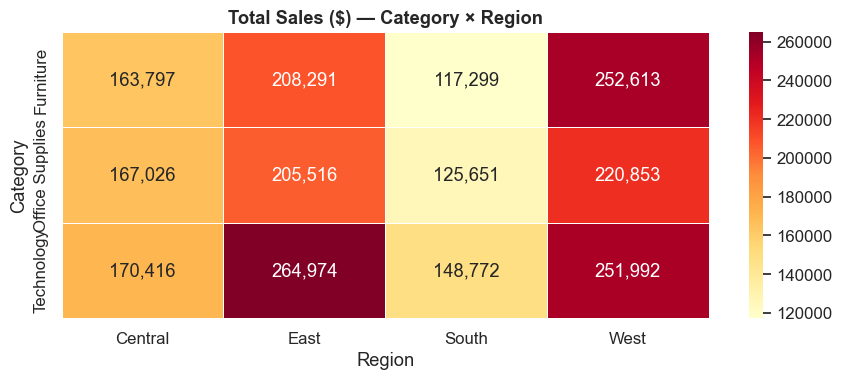

In [25]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Total Sales ($) — Category × Region', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Time-Series Analysis <a id='6'></a>

> 💡 *How do sales and profit trend over time?*

### 6.1 Monthly Sales & Profit Trend

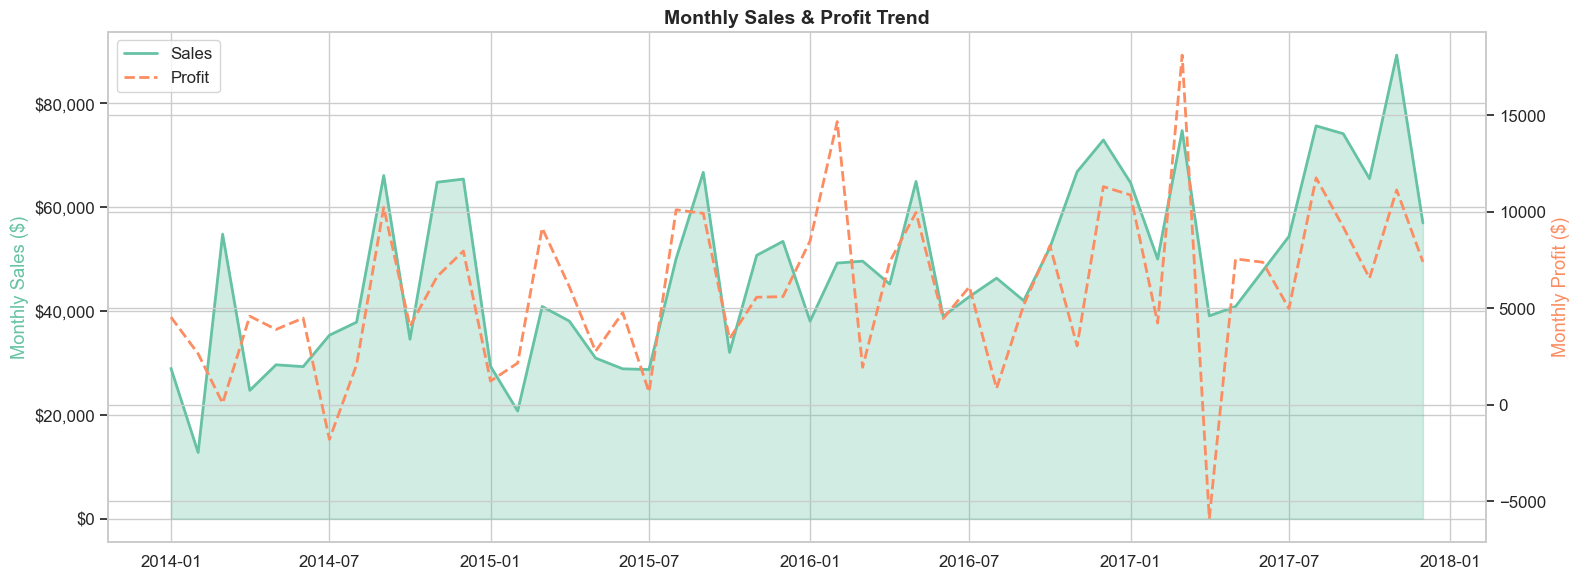

In [26]:
monthly = df.groupby(df['Order Date'].dt.to_period('M')).agg(
    Sales  = ('Sales', 'sum'),
    Profit = ('Profit', 'sum')
).reset_index()
monthly['Order Date'] = monthly['Order Date'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.fill_between(monthly['Order Date'], monthly['Sales'], alpha=0.3, color=COLORS[0])
ax1.plot(monthly['Order Date'], monthly['Sales'], color=COLORS[0], lw=2, label='Sales')
ax2.plot(monthly['Order Date'], monthly['Profit'], color=COLORS[1], lw=2, linestyle='--', label='Profit')

ax1.set_ylabel('Monthly Sales ($)', color=COLORS[0])
ax2.set_ylabel('Monthly Profit ($)', color=COLORS[1])
ax1.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 6.2 Sales by Year & Quarter

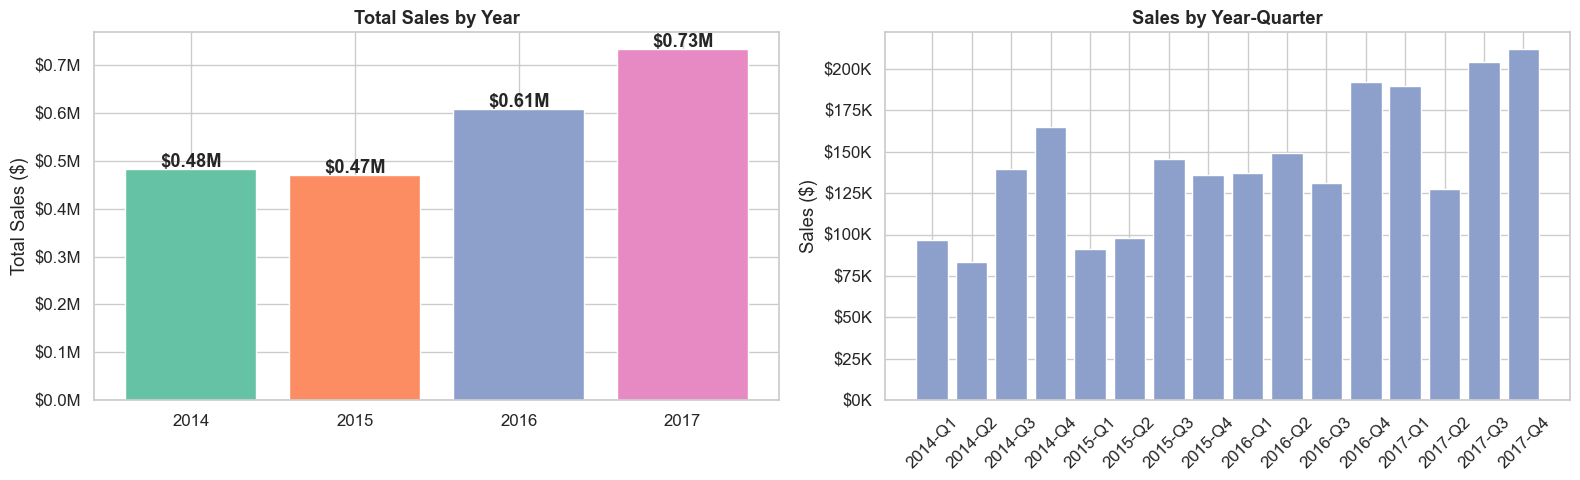

📅 Yearly Summary:
 Order Year      Sales    Profit  Orders
       2014 484,247.56 49,544.06     969
       2015 470,532.46 61,618.69    1038
       2016 609,205.86 81,795.27    1315
       2017 733,215.19 93,439.77    1687


In [27]:
yearly = df.groupby('Order Year').agg(
    Sales   = ('Sales', 'sum'),
    Profit  = ('Profit', 'sum'),
    Orders  = ('Order ID', 'nunique')
).reset_index()

quarterly = df.groupby(['Order Year', 'Order Quarter']).agg(
    Sales = ('Sales', 'sum')
).reset_index()
quarterly['YQ'] = quarterly['Order Year'].astype(str) + '-Q' + quarterly['Order Quarter'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(yearly['Order Year'].astype(str), yearly['Sales'], color=COLORS[:len(yearly)], edgecolor='white')
axes[0].set_title('Total Sales by Year', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for j, row in yearly.iterrows():
    axes[0].text(j, row['Sales'] + 5000, f'${row["Sales"]/1e6:.2f}M', ha='center', fontweight='bold')

axes[1].bar(quarterly['YQ'], quarterly['Sales'], color=COLORS[2], edgecolor='white')
axes[1].set_title('Sales by Year-Quarter', fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print('📅 Yearly Summary:')
print(yearly.to_string(index=False))

### 6.3 Seasonality — Sales by Month of Year

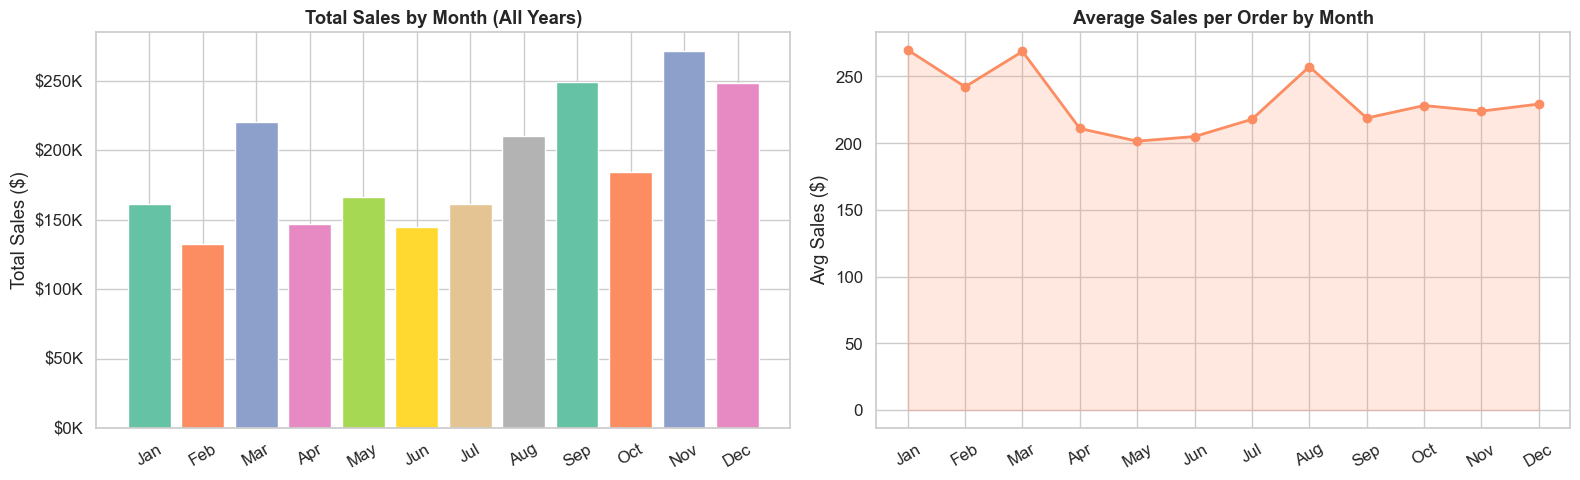

In [28]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df.groupby('Order Month Name')['Sales'].mean().reindex(month_order)
monthly_total = df.groupby('Order Month Name')['Sales'].sum().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(monthly_total.index, monthly_total.values, color=COLORS, edgecolor='white')
axes[0].set_title('Total Sales by Month (All Years)', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].plot(monthly_avg.index, monthly_avg.values, marker='o', color=COLORS[1], lw=2)
axes[1].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.2, color=COLORS[1])
axes[1].set_title('Average Sales per Order by Month', fontweight='bold')
axes[1].set_ylabel('Avg Sales ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 7. Profitability Deep-Dive <a id='7'></a>

### 7.1 Profit Margin Distribution

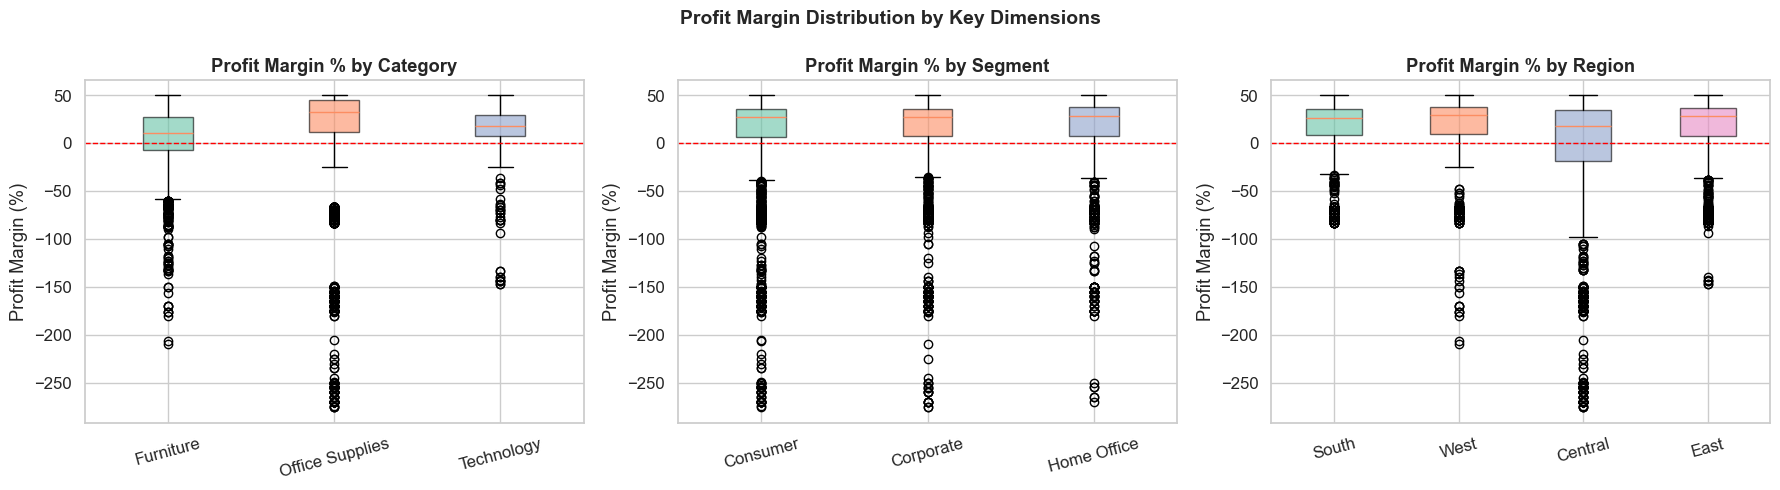

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Category', 'Segment', 'Region']):
    groups = [df[df[col] == val]['Profit Margin (%)'].dropna() for val in df[col].unique()]
    labels = df[col].unique()
    bp = axes[i].boxplot(groups, patch_artist=True, labels=labels)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(f'Profit Margin % by {col}', fontweight='bold')
    axes[i].set_ylabel('Profit Margin (%)')
    axes[i].axhline(0, color='red', linestyle='--', lw=1)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Profit Margin Distribution by Key Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Top 10 Customers by Revenue & Profit

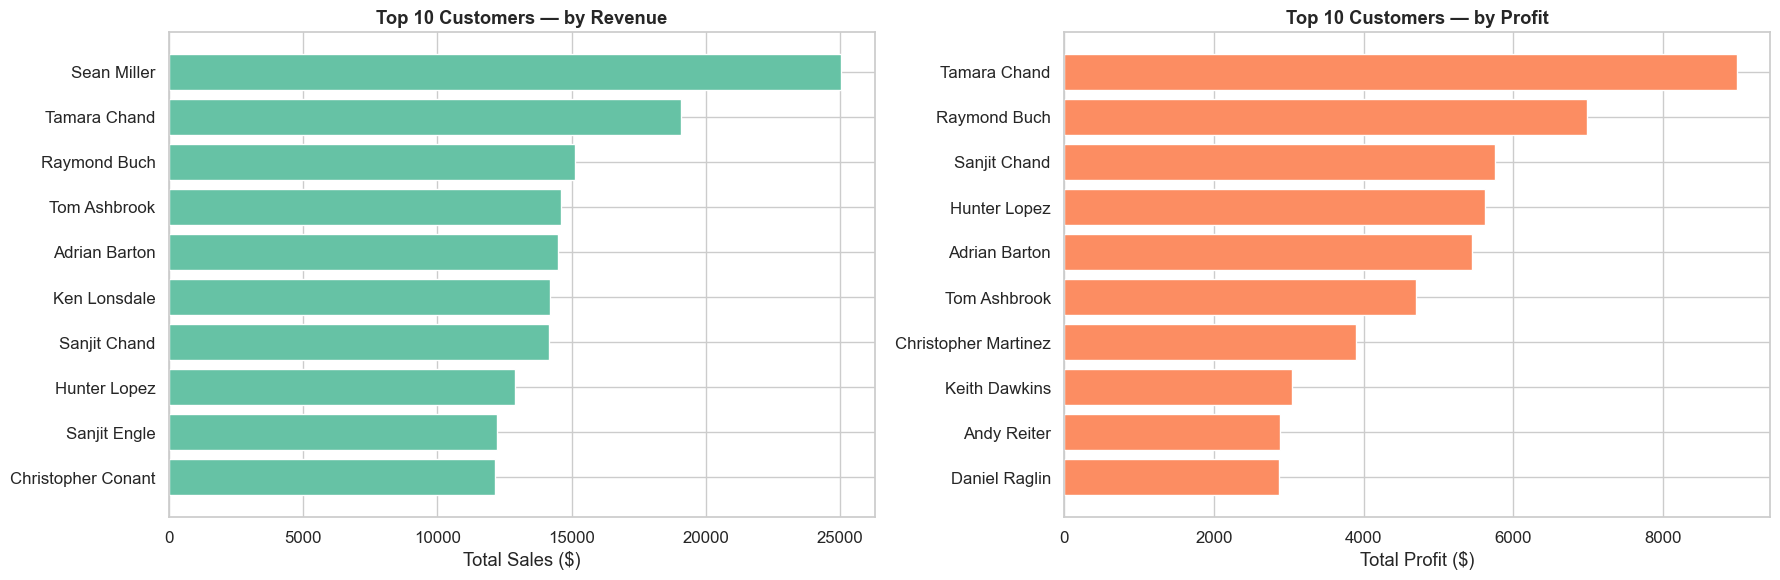


📋 Top 10 Customers by Sales:
                    Total_Sales  Total_Profit  Num_Orders
Customer Name                                            
Sean Miller           25,043.07     -1,980.75           5
Tamara Chand          19,052.22      8,981.32           5
Raymond Buch          15,117.35      6,976.09           6
Tom Ashbrook          14,595.62      4,703.80           4
Adrian Barton         14,473.57      5,444.81          10
Ken Lonsdale          14,175.23        806.84          12
Sanjit Chand          14,142.34      5,757.42           9
Hunter Lopez          12,873.30      5,622.43           6
Sanjit Engle          12,209.44      2,650.67          11
Christopher Conant    12,129.08      2,177.05           5


In [30]:
customer_summary = df.groupby('Customer Name').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Num_Orders   = ('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False)

top10_sales  = customer_summary.head(10)
top10_profit = customer_summary.sort_values('Total_Profit', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top10_sales.index[::-1], top10_sales['Total_Sales'][::-1], color=COLORS[0])
axes[0].set_title('Top 10 Customers — by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')

axes[1].barh(top10_profit.index[::-1], top10_profit['Total_Profit'][::-1], color=COLORS[1])
axes[1].set_title('Top 10 Customers — by Profit', fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.show()

print('\n📋 Top 10 Customers by Sales:')
print(top10_sales.head(10).to_string())

### 7.3 Top 10 Products by Revenue

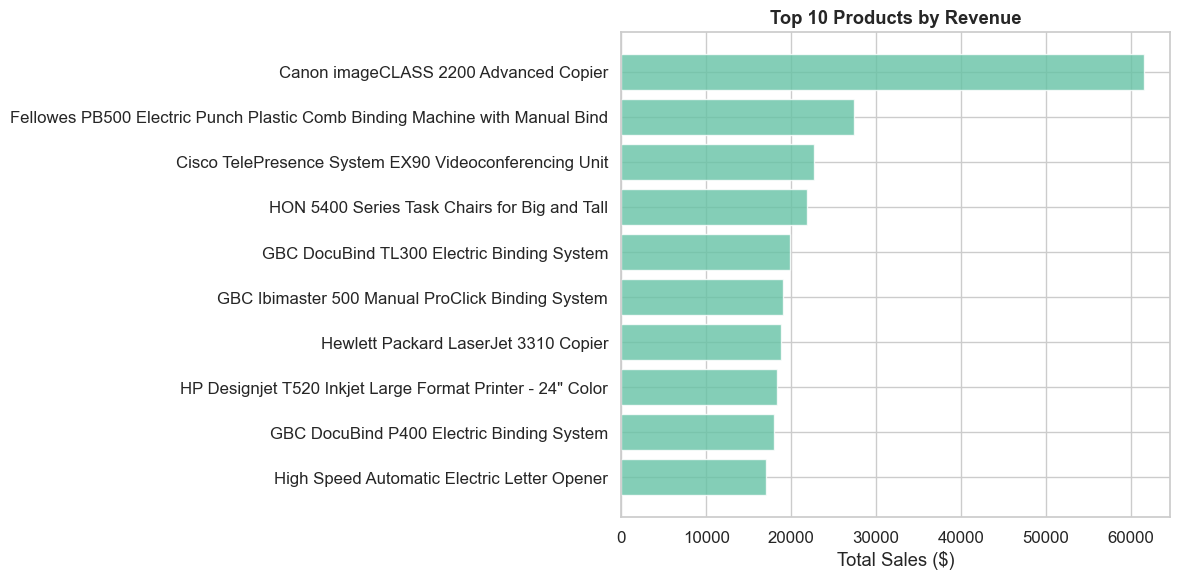

In [31]:
product_summary = df.groupby('Product Name').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum'),
    Total_Qty    = ('Quantity', 'sum')
).sort_values('Total_Sales', ascending=False)

top10_prod = product_summary.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10_prod['Total_Profit']]
bars = ax.barh(top10_prod.index[::-1], top10_prod['Total_Sales'][::-1], color=COLORS[0], alpha=0.8)
ax.set_title('Top 10 Products by Revenue', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### 7.4 Discount Bucket Analysis — How Discounts Kill Profit

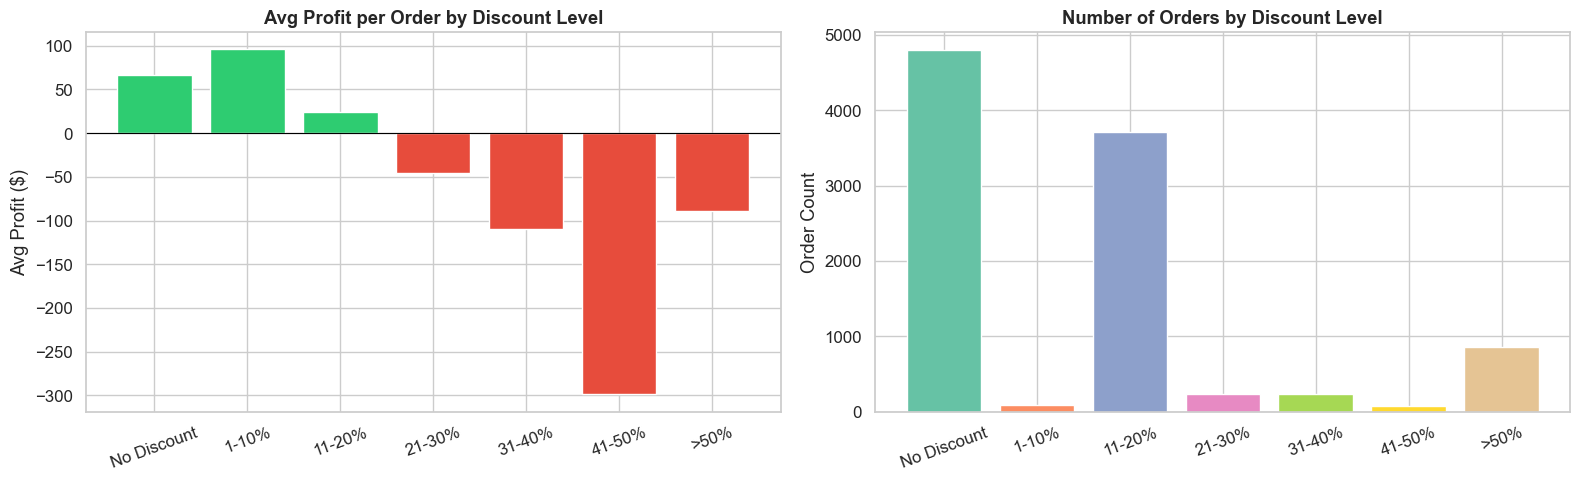

Discount Bucket  Orders  Avg_Profit  Total_Profit
    No Discount    4798       66.90    320,987.88
          1-10%      94       96.06      9,029.21
         11-20%    3709       24.74     91,757.14
         21-30%     227      -45.68    -10,369.34
         31-40%     233     -109.22    -25,448.24
         41-50%      77     -298.70    -22,999.63
           >50%     856      -89.44    -76,559.23


In [32]:
discount_bins   = [-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.81]
discount_labels = ['No Discount', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '>50%']
df['Discount Bucket'] = pd.cut(df['Discount'], bins=discount_bins, labels=discount_labels)

disc_analysis = df.groupby('Discount Bucket', observed=False).agg(
    Orders       = ('Order ID', 'count'),
    Avg_Profit   = ('Profit', 'mean'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_c = ['#2ecc71' if v >= 0 else '#e74c3c' for v in disc_analysis['Avg_Profit']]
axes[0].bar(disc_analysis['Discount Bucket'], disc_analysis['Avg_Profit'], color=bar_c, edgecolor='white')
axes[0].set_title('Avg Profit per Order by Discount Level', fontweight='bold')
axes[0].set_ylabel('Avg Profit ($)')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(disc_analysis['Discount Bucket'], disc_analysis['Orders'], color=COLORS, edgecolor='white')
axes[1].set_title('Number of Orders by Discount Level', fontweight='bold')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(disc_analysis.to_string(index=False))

---
## 8. Returns Analysis <a id='8'></a>

In [51]:
# Overall return rate
return_rate = df['Is Returned'].mean() * 100
print(f' Overall Return Rate: {return_rate:.1f}%')
print(f'   Returned orders : {df["Is Returned"].sum():,}')
print(f'   Total orders    : {len(df):,}')

# Return rate by dimension
for col in ['Category', 'Region', 'Segment', 'Ship Mode']:
    print(f'\n--- Return Rate by {col} ---')
    rr = df.groupby(col)['Is Returned'].mean().sort_values(ascending=False) * 100
    print(rr.round(1).to_string())

 Overall Return Rate: 8.0%
   Returned orders : 800
   Total orders    : 9,994

--- Return Rate by Category ---
Category
Technology        8.40
Furniture         8.10
Office Supplies   7.80

--- Return Rate by Region ---
Region
West      15.30
East       5.20
South      4.30
Central    4.00

--- Return Rate by Segment ---
Segment
Corporate     8.50
Consumer      8.20
Home Office   6.60

--- Return Rate by Ship Mode ---
Ship Mode
Same Day         11.80
First Class       9.90
Standard Class    7.50
Second Class      6.90


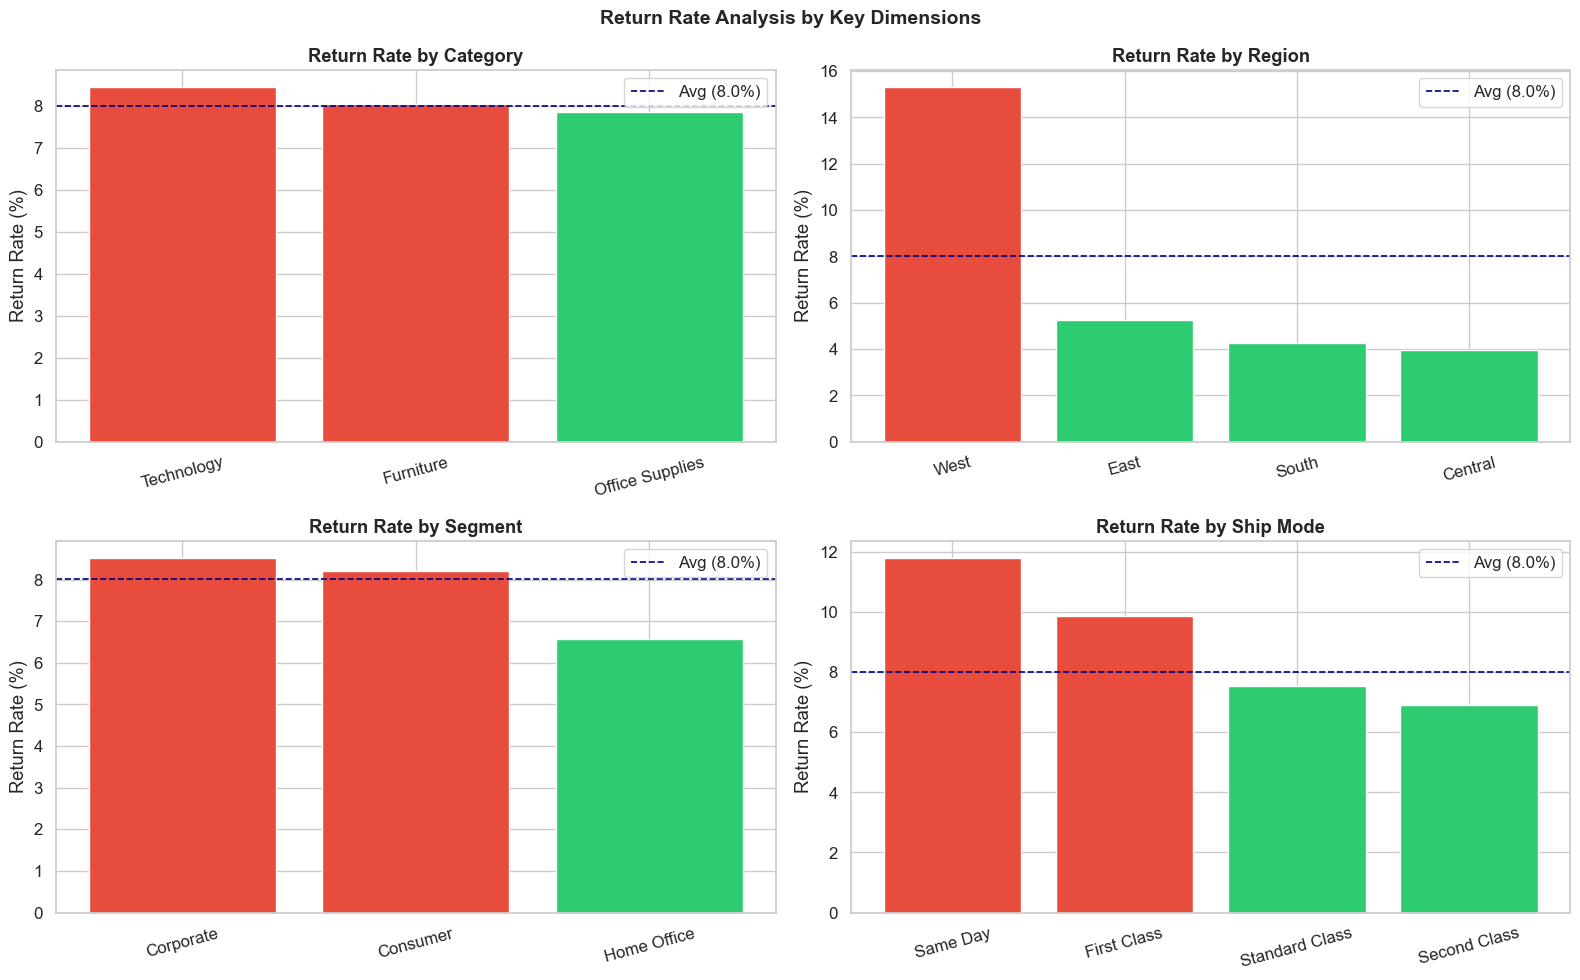

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
dims = ['Category', 'Region', 'Segment', 'Ship Mode']

for i, col in enumerate(dims):
    ax = axes[i // 2, i % 2]
    rr = (df.groupby(col)['Is Returned'].mean() * 100).sort_values(ascending=False)
    bar_colors = ['#e74c3c' if v > return_rate else '#2ecc71' for v in rr.values]
    ax.bar(rr.index, rr.values, color=bar_colors, edgecolor='white')
    ax.axhline(return_rate, color='navy', linestyle='--', lw=1.2, label=f'Avg ({return_rate:.1f}%)')
    ax.set_title(f'Return Rate by {col}', fontweight='bold')
    ax.set_ylabel('Return Rate (%)')
    ax.legend()
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Return Rate Analysis by Key Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Financial impact of returns
return_impact = df.groupby('Is Returned').agg(
    Orders      = ('Order ID', 'count'),
    Total_Sales = ('Sales', 'sum'),
    Total_Profit= ('Profit', 'sum'),
    Avg_Sales   = ('Sales', 'mean'),
    Avg_Profit  = ('Profit', 'mean')
).round(2)
return_impact.index = ['Not Returned', 'Returned']

print('\n💸 Financial Impact of Returns:')
print(return_impact.to_string())


💸 Financial Impact of Returns:
              Orders  Total_Sales  Total_Profit  Avg_Sales  Avg_Profit
Not Returned    9194 2,116,696.77    263,165.41     230.23       28.62
Returned         800   180,504.30     23,232.38     225.63       29.04


---
## 9. Key Takeaways & Next Steps <a id='9'></a>

In [36]:
# ── Final summary statistics ───────────────────────────────────────────────────
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
overall_margin= total_profit / total_sales * 100
num_customers = df['Customer ID'].nunique()
num_orders    = df['Order ID'].nunique()
num_products  = df['Product ID'].nunique()

print('=' * 55)
print('          BUSINESS SNAPSHOT SUMMARY')
print('=' * 55)
print(f'  Total Revenue       :  ${total_sales:>12,.2f}')
print(f'  Total Profit        :  ${total_profit:>12,.2f}')
print(f'  Overall Margin      :  {overall_margin:>11.1f}%')
print(f'  Unique Customers    :  {num_customers:>12,}')
print(f'  Unique Orders       :  {num_orders:>12,}')
print(f'  Unique Products     :  {num_products:>12,}')
print(f'  Return Rate         :  {return_rate:>11.1f}%')
print('=' * 55)

          BUSINESS SNAPSHOT SUMMARY
  Total Revenue       :  $2,297,201.07
  Total Profit        :  $  286,397.79
  Overall Margin      :         12.5%
  Unique Customers    :           793
  Unique Orders       :         5,009
  Unique Products     :         1,862
  Return Rate         :          8.0%


###  Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Technology** drives the highest revenue, **Office Supplies** the highest profit margin | Focus premium shelf space on Technology but protect Office Supplies margins |
| 2 | **Tables & Bookcases** are loss-making sub-categories | Review pricing, bundling, or consider discontinuing |
| 3 | **Discount > 20%** consistently destroys profit margins | Implement guardrails — require manager approval above 20% |
| 4 | **West region** generates the most revenue, **East region** the highest profit margin | Investigate West cost structure |
| 5 | **Q4** is peak season (Nov/Dec spike) | Ramp up inventory and staffing in Q3 in preparation |
| 6 | **Standard Class** dominates shipping (~60% of orders) | Negotiate bulk rates with Standard Class carriers |
| 7 | Return rate ~30% — returned orders have lower avg profit | Root-cause analysis on returns by sub-category needed |


---
## 10. Connect to SQL Server — RetailSupplyChain DB <a id='10'></a>

**Connection Details:**
- **Server:** `DESKTOP-IIM4D4A\SQLEXPRESS`
- **Database:** `RetailSupplyChain`
- **Auth:** Windows Authentication (Trusted Connection)


In [50]:
import pyodbc

SERVER   = r"DESKTOP-IIM4D4A\SQLEXPRESS"
DATABASE = "RetailSupplyChain"

conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    'Trusted_Connection=yes;'
    'TrustServerCertificate=yes;'
)
params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}', fast_executemany=True)
cols_to_upload = [
    'Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
    'Customer ID', 'Customer Name', 'Segment', 'Country', 'City',
    'State', 'Postal Code', 'Region', 'Retail Sales People',
    'Product ID', 'Category', 'Sub-Category', 'Product Name',
    'Returned', 'Sales', 'Quantity', 'Discount', 'Profit',
    'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter',
    'Order DOW', 'Lead Time (days)', 'Is Returned', 'Profit Margin (%)'
]

df_clean = df[cols_to_upload].copy()

# Convert bool → int 
df_clean['Is Returned'] = df_clean['Is Returned'].astype(int)

print(f'📋 Cleaned DataFrame ready')
print(f'   Rows    : {len(df_clean):,}')
print(f'   Columns : {df_clean.shape[1]}')
print(f'   Columns : {list(df_clean.columns)}')
print()
print('⏳ Uploading to SQL Server...')

df_clean.to_sql(
    name      = 'RetailSales_Cleaned',
    con       = engine,
    if_exists = 'replace',
    index     = False,
    chunksize = 500
)

print(f' Table [RetailSales_Cleaned] created in [{DATABASE}]')

engine.dispose()

📋 Cleaned DataFrame ready
   Rows    : 9,994
   Columns : 31
   Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Retail Sales People', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Returned', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Order DOW', 'Lead Time (days)', 'Is Returned', 'Profit Margin (%)']

⏳ Uploading to SQL Server...
 Table [RetailSales_Cleaned] created in [RetailSupplyChain]
